<a href="https://colab.research.google.com/github/SathishKentState/Sathish-Babu-Nuthi_Advanced-Machine-Learning/blob/main/Sathish__Babu__Nuthi__BA74067Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Data Set Preparation**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


zip_path = keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    extract=True
)

csv_path = os.path.join(zip_path, "jena_climate_2009_2016.csv")
df = pd.read_csv(csv_path)
raw_data = df.iloc[:, 1:].values


num_samples = len(raw_data)
train_end = int(num_samples * 0.5)
val_end = int(num_samples * 0.75)


mean = raw_data[:train_end].mean(axis=0)
std = raw_data[:train_end].std(axis=0)
raw_data = (raw_data - mean) / std

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
sampling_rate = 6
sequence_length = 120
delay = 24
batch_size = 256

def make_dataset(data, shuffle=False):

    targets = data[delay:, 1]
    return keras.utils.timeseries_dataset_from_array(
        data[:-delay],
        targets=targets,
        sequence_length=sequence_length,
        sampling_rate=sampling_rate,
        batch_size=batch_size,
        shuffle=shuffle
    )

train_dataset = make_dataset(raw_data[:train_end], shuffle=True)
val_dataset = make_dataset(raw_data[train_end:val_end])
test_dataset = make_dataset(raw_data[val_end:])

In [ ]:
results = []

def train_and_evaluate_model(model, model_name, epochs=20):
    print(f"\n--- Training {model_name} ---")
    checkpoint_path = f"{model_name.replace(' ', '_').lower()}.keras"

    callbacks = [
        keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor="val_mae"),
        keras.callbacks.EarlyStopping(monitor="val_mae", patience=5, restore_best_weights=True)
    ]

    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    history = model.fit(train_dataset, epochs=epochs, validation_data=val_dataset, callbacks=callbacks)


    best_model = keras.models.load_model(checkpoint_path)
    val_mae = best_model.evaluate(val_dataset, verbose=0)[1]
    test_mae = best_model.evaluate(test_dataset, verbose=0)[1]

    results.append({
        "Model": model_name,
        "Best Validation MAE": val_mae,
        "Test MAE": test_mae
    })
    return history

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


sampling_rate = 6
sequence_length = 120
delay = 24
batch_size = 256



**Model 1: GRU Baseline with 16 Layers**

In [ ]:
# Model 1 architecture ---

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))


x = layers.GRU(16)(inputs)


outputs = layers.Dense(1)(x)

model_gru = keras.Model(inputs, outputs)
model_gru.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 16)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,553 (6.07 KB)

 Trainable params: 1,553 (6.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Model 1 GRU baseline training ---
history_gru = train_and_evaluate_model(model_gru, "GRU Baseline")


best_epoch_gru = np.argmin(history_gru.history["val_mae"]) + 1

print(f"\n>>> Best Epoch for GRU Baseline: {best_epoch_gru}")


--- Training GRU Baseline ---
Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 61ms/step - loss: 0.3352 - mae: 0.4445 - val_loss: 0.1938 - val_mae: 0.3402
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 0.1000 - mae: 0.2384 - val_loss: 0.0611 - val_mae: 0.1874
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 56s 68ms/step - loss: 0.0484 - mae: 0.1673 - val_loss: 0.0527 - val_mae: 0.1740
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 0.0314 - mae: 0.1340 - val_loss: 0.0211 - val_mae: 0.1067
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 59ms/step - loss: 0.0190 - mae: 0.1033 - val_loss: 0.0122 - val_mae: 0.0813
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 83s 60ms/step - loss: 0.0122 - mae: 0.0826 - val_loss: 0.0094 - val_mae: 0.0699
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 60ms/step - loss: 0.0085 - mae: 0.0687 - val_loss: 0.0052 - val_mae: 0.0516
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 50s 61ms/step - loss: 0.0063 - mae: 0.0588 - val_loss: 0.0039 - val_mae: 0.0451
Epoch 9/2

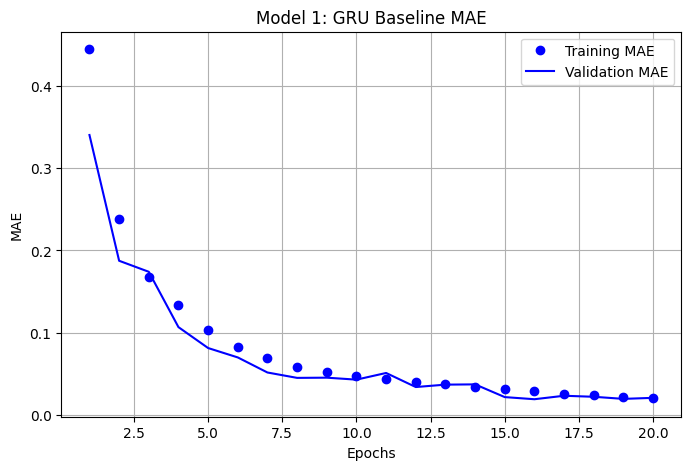

In [ ]:
#--- Model 1 Performance Plotting ---
epochs_range = range(1, len(history_gru.history["mae"]) + 1)

plt.figure(figsize=(8, 5))


plt.plot(epochs_range, history_gru.history["mae"], "bo", label="Training MAE")
plt.plot(epochs_range, history_gru.history["val_mae"], "b", label="Validation MAE")

plt.title("Model 1: GRU Baseline MAE") # [cite: 122]
plt.xlabel("Epochs") # [cite: 123]
plt.ylabel("MAE") # [cite: 124]
plt.legend() # [cite: 124]
plt.grid(True) # [cite: 124]
plt.show() # [cite: 124]

**Model 2A: Stacked GRU  **

In [ ]:
#--- Model 2 Stacked GRU Architecute ---
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.GRU(32, return_sequences=True, recurrent_dropout=0.5)(inputs)

x = layers.GRU(32, recurrent_dropout=0.5)(x)

x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model_stacked_gru = keras.Model(inputs, outputs)
model_stacked_gru.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 120, 32)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,977 (42.88 KB)

 Trainable params: 10,977 (42.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Model 2: Training and Best Epoch ---
history_stacked_gru = train_and_evaluate_model(model_stacked_gru, "Stacked GRU")


best_epoch_val = np.argmin(history_stacked_gru.history["val_mae"]) +
print(f"\n>>> Best Epoch for Stacked GRU: {best_epoch_val}")


--- Training Stacked GRU ---
Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 636s 772ms/step - loss: 0.3650 - mae: 0.4742 - val_loss: 0.1659 - val_mae: 0.3206
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 634s 774ms/step - loss: 0.1149 - mae: 0.2558 - val_loss: 0.0243 - val_mae: 0.1186
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 635s 775ms/step - loss: 0.0634 - mae: 0.1879 - val_loss: 0.0142 - val_mae: 0.0926
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 627s 766ms/step - loss: 0.0533 - mae: 0.1691 - val_loss: 0.0131 - val_mae: 0.0915
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 627s 766ms/step - loss: 0.0485 - mae: 0.1596 - val_loss: 0.0107 - val_mae: 0.0789
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 626s 765ms/step - loss: 0.0457 - mae: 0.1543 - val_loss: 0.0071 - val_mae: 0.0624
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 625s 762ms/step - loss: 0.0438 - mae: 0.1501 - val_loss: 0.0088 - val_mae: 0.0731
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 624s 761ms/step - loss: 0.0424 - mae: 0.1472 - val_loss: 0.0049 - val_mae: 0

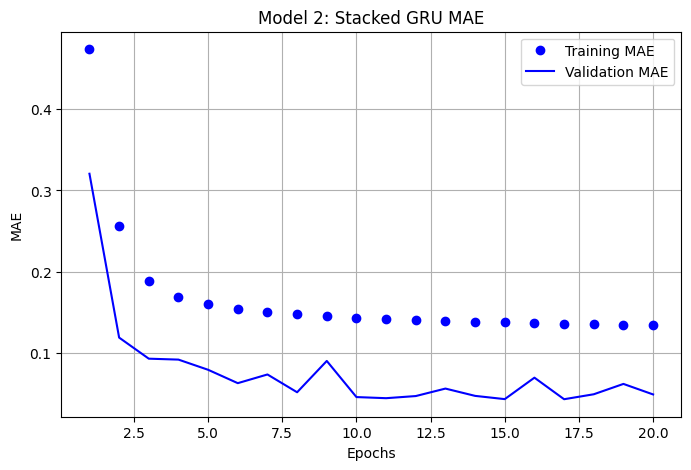

In [ ]:
# --- Model 2: Performance Plotting ---
epochs_range = range(1, len(history_stacked_gru.history["mae"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_stacked_gru.history["mae"], "bo", label="Training MAE")
plt.plot(epochs_range, history_stacked_gru.history["val_mae"], "b", label="Validation MAE")
plt.title("Model 2: Stacked GRU MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

**Model 2B Adjusting number of units in stacked GRU**

In [ ]:

# ---- Model 2B Stacking and Evaluation ----


unit_configs = [16, 32, 64]

histories = {}

for units in unit_configs:
    print(f"\n==============================")
    print(f"Training Stacked GRU with {units}-{units} units")
    print(f"==============================")


    inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

    x = layers.GRU(units, return_sequences=True, recurrent_dropout=0.5)(inputs)
    x = layers.GRU(units, recurrent_dropout=0.5)(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs)

    history = train_and_evaluate_model(
        model,
        f"Stacked GRU ({units}-{units})"
    )

    histories[f"{units}-{units}"] = history


Training Stacked GRU with 16-16 units

--- Training Stacked GRU (16-16) ---
Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 203s 241ms/step - loss: 0.4449 - mae: 0.5219 - val_loss: 0.2710 - val_mae: 0.4109
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 203s 248ms/step - loss: 0.2281 - mae: 0.3653 - val_loss: 0.0499 - val_mae: 0.1708
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 198s 241ms/step - loss: 0.1182 - mae: 0.2574 - val_loss: 0.0299 - val_mae: 0.1314
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 198s 241ms/step - loss: 0.0965 - mae: 0.2290 - val_loss: 0.0208 - val_mae: 0.1082
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 203s 243ms/step - loss: 0.0877 - mae: 0.2153 - val_loss: 0.0150 - val_mae: 0.0923
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 196s 239ms/step - loss: 0.0831 - mae: 0.2082 - val_loss: 0.0123 - val_mae: 0.0826
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 196s 239ms/step - loss: 0.0800 - mae: 0.2023 - val_loss: 0.0175 - val_mae: 0.1008
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 195s 237ms/step - loss: 0.078

** Model 3:Using LSTM Instead of GRU( LSTM Architecture ) **

In [ ]:
#--- Model 3 Architecture ---
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1)(x)
model_lstm = keras.Model(inputs, outputs)
model_lstm.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │         6,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,049 (23.63 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Model 3: Training and Best Epoch Identification ---
history_lstm = train_and_evaluate_model(model_lstm, "LSTM")


best_epoch_lstm = np.argmin(history_lstm.history["val_mae"]) + 1
print(f"\n>>> Best Epoch for LSTM: {best_epoch_lstm}")


--- Training LSTM ---
Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 117s 140ms/step - loss: 0.2006 - mae: 0.3481 - val_loss: 0.1526 - val_mae: 0.3074
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 117s 142ms/step - loss: 0.1669 - mae: 0.3194 - val_loss: 0.1444 - val_mae: 0.2975
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 116s 141ms/step - loss: 0.1616 - mae: 0.3139 - val_loss: 0.1414 - val_mae: 0.2934
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 113s 137ms/step - loss: 0.1581 - mae: 0.3101 - val_loss: 0.1421 - val_mae: 0.2938
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 108s 132ms/step - loss: 0.1570 - mae: 0.3087 - val_loss: 0.1420 - val_mae: 0.2933
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 108s 132ms/step - loss: 0.1558 - mae: 0.3078 - val_loss: 0.1414 - val_mae: 0.2924
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 112s 136ms/step - loss: 0.1543 - mae: 0.3061 - val_loss: 0.1408 - val_mae: 0.2915
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 146s 142ms/step - loss: 0.1536 - mae: 0.3055 - val_loss: 0.1428 - val_mae: 0.2935
E

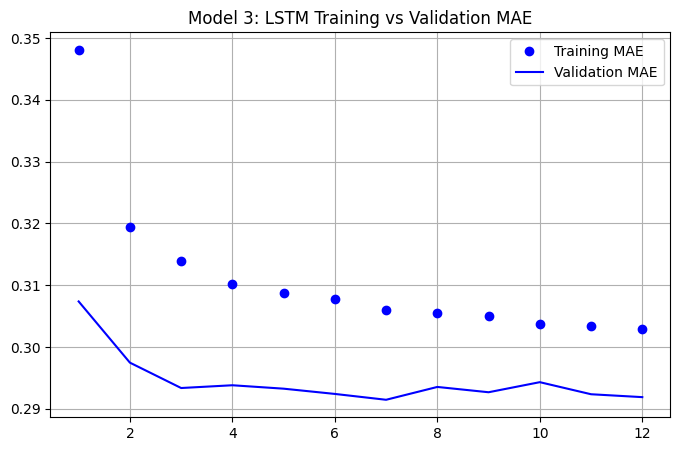

In [ ]:
# --- Model 3: Performance Plotting ---
epochs_range = range(1, len(history_lstm.history["mae"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_lstm.history["mae"], "bo", label="Training MAE")
plt.plot(epochs_range, history_lstm.history["val_mae"], "b", label="Validation MAE")
plt.title("Model 3: LSTM Training vs Validation MAE")
plt.legend(); plt.grid(True); plt.show()

**Using a Combination of 1D ConvNets and RNN**

In [ ]:
# --- Model 4: Conv1D + GRU Architecture ---

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))


x = layers.Conv1D(32, 5, activation="relu")(inputs)


x = layers.MaxPooling1D(3)(x)


x = layers.GRU(32)(x)


x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1)(x)
model_conv_gru = keras.Model(inputs, outputs)
model_conv_gru.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 120, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 116, 32)        │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 38, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,641 (33.75 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Model 4: Training and Best Epoch Identification ---

history_conv_gru = train_and_evaluate_model(
    model_conv_gru,
    "Conv1D + GRU",
    epochs=20
)

best_epoch_conv_gru = np.argmin(history_conv_gru.history["val_mae"]) + 1

print(f"\n>>> Best Epoch for Conv1D + GRU: {best_epoch_conv_gru}")


--- Training Conv1D + GRU ---
Epoch 1/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 74s 87ms/step - loss: 0.2321 - mae: 0.3736 - val_loss: 0.4633 - val_mae: 0.5517
Epoch 2/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 68s 83ms/step - loss: 0.1863 - mae: 0.3370 - val_loss: 0.3969 - val_mae: 0.5096
Epoch 3/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 73s 90ms/step - loss: 0.1776 - mae: 0.3290 - val_loss: 0.3733 - val_mae: 0.4937
Epoch 4/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 74s 90ms/step - loss: 0.1731 - mae: 0.3250 - val_loss: 0.3560 - val_mae: 0.4814
Epoch 5/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 72s 88ms/step - loss: 0.1686 - mae: 0.3211 - val_loss: 0.3456 - val_mae: 0.4735
Epoch 6/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 74s 91ms/step - loss: 0.1653 - mae: 0.3178 - val_loss: 0.3286 - val_mae: 0.4591
Epoch 7/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 72s 87ms/step - loss: 0.1626 - mae: 0.3154 - val_loss: 0.3196 - val_mae: 0.4518
Epoch 8/20
819/819 ━━━━━━━━━━━━━━━━━━━━ 73s 89ms/step - loss: 0.1609 - mae: 0.3138 - val_loss: 0.3012 - val_mae: 0.4396
Epoch 9/2

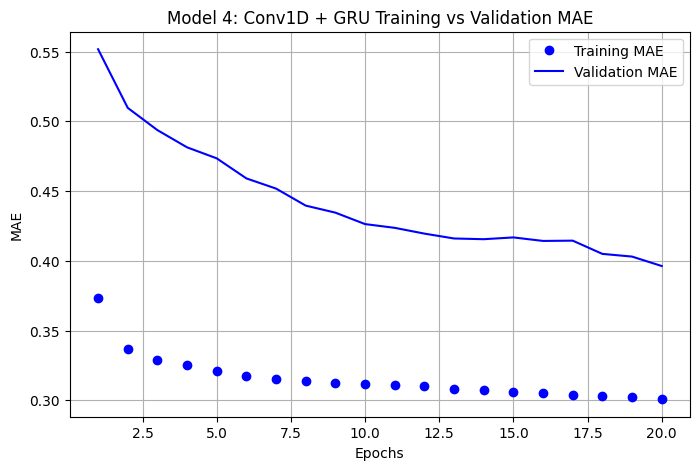

In [ ]:
# --- Model 4: Performance Plotting ---
epochs_range = range(1, len(history_conv_gru.history["mae"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history_conv_gru.history["mae"], "bo", label="Training MAE")
plt.plot(epochs_range, history_conv_gru.history["val_mae"], "b", label="Validation MAE")

plt.title("Model 4: Conv1D + GRU Training vs Validation MAE") #
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()